# Trash-ICRA19 Exploration (PRIMARY DATASET)
**Assigned to:** ___
**No GPU needed. CPU runtime is fine.**

This is our MAIN training dataset. Everything depends on understanding this correctly.

In [1]:
import os
from pathlib import Path

def _in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "configs").exists() and (p / "src").exists():
            return p
    return start

def _looks_like_dataset_root(p: Path) -> bool:
    # Accept either flat split layout (train/*.jpg) or Ultralytics layout (train/images/*.jpg)
    if not p.exists() or not p.is_dir():
        return False
    has_splits = all((p / s).exists() for s in ("train", "val", "test"))
    if not has_splits:
        return False
    return True

def _autodetect_nested_root(root: Path) -> Path:
    # Common case: Drive folder contains a nested 'dataset/' folder with splits
    for name in ("dataset", "Dataset", "data", "Data"):
        cand = root / name
        if _looks_like_dataset_root(cand):
            return cand
    # Light-weight search up to depth 2 (avoid expensive full rglob)
    queue = [root]
    seen = set()
    max_dirs = 300
    while queue and len(seen) < max_dirs:
        cur = queue.pop(0)
        if cur in seen:
            continue
        seen.add(cur)
        try:
            for child in cur.iterdir():
                if not child.is_dir():
                    continue
                if _looks_like_dataset_root(child):
                    return child
                # only go 2 levels deep from original root
                if child.parent == root:
                    queue.append(child)
        except Exception:
            continue
    return root

# If you're in Colab, mount Drive; locally (Windows/Linux/macOS) skip this.
if _in_colab():
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')

# You can override this from your shell: set TRASH_ICRA19_DIR=...
env_ds = os.environ.get("TRASH_ICRA19_DIR")

repo_root = _find_repo_root(Path.cwd())
candidates = []
if env_ds:
    candidates.append(Path(env_ds))

# Repo-expected default (see configs/datasets/trash_icra19.yaml)
candidates += [
    repo_root / "data" / "processed",
    repo_root / "data" / "processed" / "trash_ICRA19",
    repo_root / "data" / "raw" / "trash-icra19" / "trash_ICRA19" / "dataset",
    repo_root / "data" / "raw" / "trash-icra19",
    repo_root / "data" / "raw" / "trash_icra19",
    repo_root / "data" / "raw" / "trash_ICRA19",
    repo_root / "data" / "raw" / "trash_ICRA19" / "dataset",
    repo_root / "data" / "trash_ICRA19",
    repo_root / "data" / "trash_icra19",
 ]

# Colab default (kept for compatibility)
if _in_colab():
    candidates.append(Path("/content/drive/MyDrive/underwater_datasets/trash_ICRA19"))

DATASET = None
for p in candidates:
    if p.exists():
        # If user points at a parent folder, try to step into the true dataset root
        p2 = _autodetect_nested_root(p)
        DATASET = str(p2)
        break

if DATASET is None:
    msg = "\n".join([f"- {p}" for p in candidates])
    raise FileNotFoundError(
        "Could not locate Trash-ICRA19 dataset root. Tried:\n" + msg + "\n\n"
        "Fix: set environment variable TRASH_ICRA19_DIR to your dataset folder."
    )

print(f"✓ Dataset: {DATASET}")

# Quick sanity check for expected split layout
root = Path(DATASET)
expected = [root / "train", root / "val", root / "test"]
if not all(p.exists() for p in expected):
    print("[WARN] Expected split folders train/val/test not found under DATASET.")
    print("       Double-check TRASH_ICRA19_DIR or DATASET.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset


In [2]:
# === FULL FOLDER STRUCTURE ===
from pathlib import Path
from collections import Counter

root = Path(DATASET)
for dirpath, dirnames, filenames in sorted(os.walk(root)):
    depth = str(dirpath).replace(str(root), "").count(os.sep)
    if depth > 3: continue
    indent = "  " * depth
    exts = Counter(Path(f).suffix.lower() for f in filenames)
    print(f"{indent}{os.path.basename(dirpath)}/")
    for ext, cnt in sorted(exts.items()):
        print(f"{indent}  {cnt:>6} {ext}")


dataset/
       1 .txt
  test/
      1144 .jpg
      1144 .txt
      1145 .xml
  train/
      5724 .jpg
      5723 .txt
      5722 .xml
  val/
       820 .jpg
       820 .txt
       820 .xml
  videos_for_testing/
         3 .mp4


In [3]:
# === PER-SPLIT STATS ===
from pathlib import Path

root = Path(DATASET)
IMG_EXTS = (".jpg", ".jpeg", ".png")

def _resolve_split_dirs(root: Path, split: str) -> tuple[Path, Path]:
    """Return (images_dir, labels_dir) for a split, handling common layouts."""
    base = root / split
    if not base.exists():
        return base, base
    img_dir = base / "images" if (base / "images").exists() else base
    label_dir = base / "labels" if (base / "labels").exists() else base
    return img_dir, label_dir

for split in ["train", "val", "test"]:
    base = root / split
    if not base.exists():
        print(f"  ✗ {split}/ NOT FOUND (looked for: {base})")
        continue

    img_dir, label_dir = _resolve_split_dirs(root, split)
    imgs = set()
    for ext in IMG_EXTS:
        imgs.update(f.stem for f in img_dir.glob(f"*{ext}"))
    labels = set(f.stem for f in label_dir.glob("*.txt")) if label_dir.exists() else set()

    print(f"\n--- {split.upper()} ---")
    print(f"  Images dir: {img_dir}")
    print(f"  Labels dir: {label_dir}")
    print(f"  Images: {len(imgs)}")
    print(f"  Labels: {len(labels)}")
    print(f"  Images without labels: {len(imgs - labels)}")
    print(f"  Labels without images: {len(labels - imgs)}")
    if imgs - labels:
        print(f"    Examples: {list(imgs - labels)[:3]}")

    if len(imgs) == 0:
        print("  [WARN] No images found for this split.")
    if len(labels) == 0:
        print("  [WARN] No labels found for this split.")


--- TRAIN ---
  Images dir: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset/train
  Labels dir: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset/train
  Images: 5724
  Labels: 5723
  Images without labels: 1
  Labels without images: 0
    Examples: ['obj1658_frame0002383 (1)']

--- VAL ---
  Images dir: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset/val
  Labels dir: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset/val
  Images: 820
  Labels: 820
  Images without labels: 0
  Labels without images: 0

--- TEST ---
  Images dir: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset/test
  Labels dir: /content/drive/MyDrive/underwater_datasets/trash_ICRA19/dataset/test
  Images: 1144
  Labels: 1144
  Images without labels: 0
  Labels without images: 0


In [4]:
# Fast version: bulk copy to local disk first, then analyze
import os, subprocess
from pathlib import Path
from collections import Counter, defaultdict

LOCAL = Path("/content/local_data")
LOCAL.mkdir(exist_ok=True)

# Bulk copy all .txt files to local disk (~1-2 min vs 50+ min)
for split in ["train", "val", "test"]:
    src = Path(DATASET) / split
    if not src.exists():
        continue
    dst = LOCAL / split
    dst.mkdir(exist_ok=True)
    subprocess.run(f"cp {src}/*.txt {dst}/ 2>/dev/null", shell=True)
    print(f"  {split}: {len(list(dst.glob('*.txt')))} labels copied")

print("✓ Labels on local disk. Now analyzing...\n")

# Analyze from local disk (instant)
overall = Counter()
per_split = defaultdict(Counter)

for split in ["train", "val", "test"]:
    d = LOCAL / split
    if not d.exists(): continue
    for txt in d.glob("*.txt"):
        for line in open(txt):
            parts = line.strip().split()
            if len(parts) == 5:
                try:
                    cls = int(parts[0])
                    overall[cls] += 1
                    per_split[split][cls] += 1
                except: pass

total = sum(overall.values())
print(f"{'Class':>6} {'train':>8} {'val':>8} {'test':>8} {'Total':>8} {'%':>7}")
print("-"*50)
for cls in sorted(overall):
    t = per_split["train"].get(cls,0)
    v = per_split["val"].get(cls,0)
    te = per_split["test"].get(cls,0)
    pct = overall[cls]/total*100
    print(f"  {cls:>4} {t:>8} {v:>8} {te:>8} {overall[cls]:>8} {pct:>6.1f}%")
print(f"\nTotal: {total} boxes | Classes: {len(overall)}")

  train: 5723 labels copied
  val: 820 labels copied
  test: 1144 labels copied
✓ Labels on local disk. Now analyzing...

 Class    train      val     test    Total       %
--------------------------------------------------
     0     4582      853      937     6372   57.6%
     1     1951       70      396     2417   21.8%
     2     1802      141      335     2278   20.6%

Total: 11067 boxes | Classes: 3


In [5]:
'''# === CLASS DISTRIBUTION (CRITICAL) ===
from collections import Counter, defaultdict
from pathlib import Path

root = Path(DATASET)
overall = Counter()
per_split = defaultdict(Counter)
bad = 0

for split in ["train", "val", "test"]:
    d = root / split
    if not d.exists(): continue
    for txt in d.glob("*.txt"):
        try:
            for line in open(txt):
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = int(parts[0])
                    overall[cls] += 1
                    per_split[split][cls] += 1
        except: bad += 1

total = sum(overall.values())
print("="*65)
print(f"{'Class':>6} {'train':>8} {'val':>8} {'test':>8} {'Total':>8} {'%':>7}")
print("-"*65)
for cls in sorted(overall):
    t = per_split["train"].get(cls,0)
    v = per_split["val"].get(cls,0)
    te = per_split["test"].get(cls,0)
    pct = overall[cls]/total*100
    print(f"  {cls:>4} {t:>8} {v:>8} {te:>8} {overall[cls]:>8} {pct:>6.1f}%")
print("-"*65)
print(f"Total: {total} boxes | Classes: {len(overall)} | Errors: {bad}")

mx, mn = max(overall.values()), min(overall.values())
print(f"\nImbalance ratio: {mx/mn:.1f}x" if mn > 0 else "")'''


'# === CLASS DISTRIBUTION (CRITICAL) ===\nfrom collections import Counter, defaultdict\nfrom pathlib import Path\n\nroot = Path(DATASET)\noverall = Counter()\nper_split = defaultdict(Counter)\nbad = 0\n\nfor split in ["train", "val", "test"]:\n    d = root / split\n    if not d.exists(): continue\n    for txt in d.glob("*.txt"):\n        try:\n            for line in open(txt):\n                parts = line.strip().split()\n                if len(parts) == 5:\n                    cls = int(parts[0])\n                    overall[cls] += 1\n                    per_split[split][cls] += 1\n        except: bad += 1\n\ntotal = sum(overall.values())\nprint("="*65)\nprint(f"{\'Class\':>6} {\'train\':>8} {\'val\':>8} {\'test\':>8} {\'Total\':>8} {\'%\':>7}")\nprint("-"*65)\nfor cls in sorted(overall):\n    t = per_split["train"].get(cls,0)\n    v = per_split["val"].get(cls,0)\n    te = per_split["test"].get(cls,0)\n    pct = overall[cls]/total*100\n    print(f"  {cls:>4} {t:>8} {v:>8} {te:>8} {

In [6]:
# === BOUNDING BOX VALIDATION ===
from pathlib import Path
root = Path(DATASET)

issues = {"outside_01": 0, "zero_dim": 0, "too_large": 0, "too_small": 0}
total = 0

for txt in root.rglob("*.txt"):
    try:
        for line in open(txt):
            parts = line.strip().split()
            if len(parts) != 5: continue
            try:
                c, x, y, w, h = int(parts[0]), *map(float, parts[1:])
                total += 1
                if not (0<=x<=1 and 0<=y<=1): issues["outside_01"] += 1
                if w<=0 or h<=0: issues["zero_dim"] += 1
                if w>0.95 or h>0.95: issues["too_large"] += 1
                if w*h < 0.0001: issues["too_small"] += 1
            except ValueError: pass
    except: pass

print(f"Total boxes checked: {total}")
for name, cnt in issues.items():
    s = "✓" if cnt == 0 else "⚠️"
    print(f"  {s} {name}: {cnt} ({cnt/total*100:.2f}%)" if total else f"  {name}: {cnt}")


Total boxes checked: 11067
  ✓ outside_01: 0 (0.00%)
  ⚠️ zero_dim: 1 (0.01%)
  ⚠️ too_large: 589 (5.32%)
  ⚠️ too_small: 1 (0.01%)


In [7]:
# === IMAGE SIZE ANALYSIS ===
import cv2, numpy as np
from pathlib import Path
from collections import Counter

root = Path(DATASET)
all_imgs = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    all_imgs += list(root.rglob(ext))
all_imgs = sorted(all_imgs)

if not all_imgs:
    raise FileNotFoundError(f"No images found under: {root}")

step = max(1, len(all_imgs)//200)
samples = all_imgs[::step]

widths, heights = [], []
sizes = Counter()

print(f"Sampling {len(samples)} of {len(all_imgs)} images...")
for p in samples:
    img = cv2.imread(str(p))
    if img is None:
        continue
    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)
    sizes[f"{w}x{h}"] += 1

if not widths or not heights:
    raise RuntimeError("Could not read any sampled images (cv2.imread returned None).")

print(f"\nWidth:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")
print(f"\nMost common sizes:")
for s, c in sizes.most_common(5):
    print(f"  {s}: {c}")

Sampling 203 of 7688 images...

Width:  min=480, max=480, mean=480
Height: min=270, max=360, mean=330

Most common sizes:
  480x360: 135
  480x270: 68


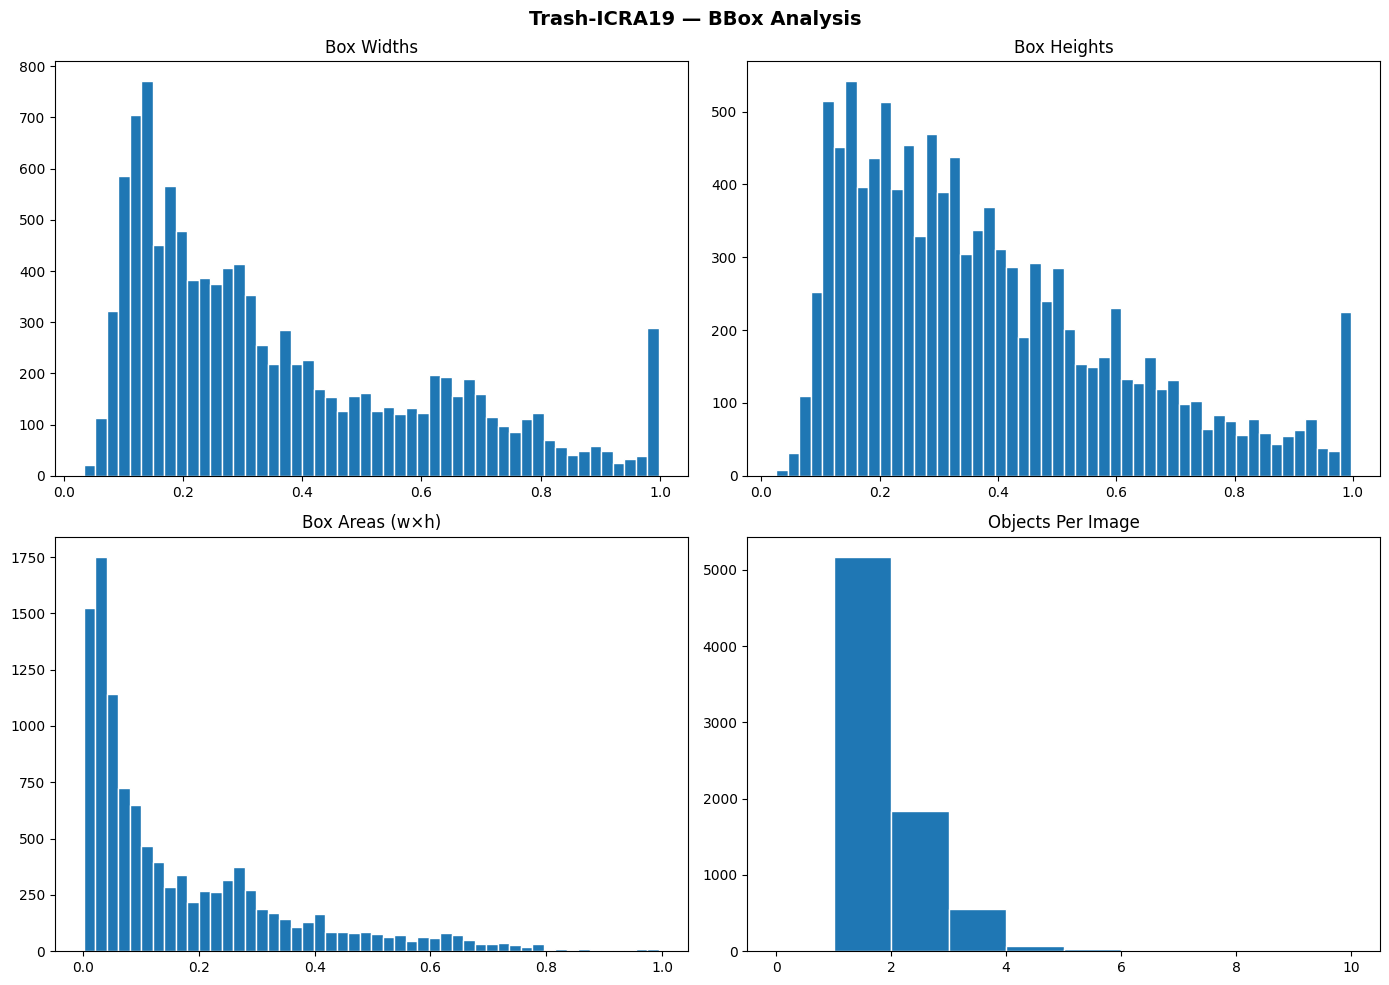

Saved figure: results/figures/trash_icra19_bbox.png
Small (<1%): 388 (3.5%)
Medium (1-10%): 5387 (48.7%)
Large (>10%): 5291 (47.8%)
Objects/image: mean=1.4, max=9


In [8]:
# === BBOX SIZE DISTRIBUTION ===
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path

root = Path(DATASET)
areas, bw_list, bh_list, per_img = [], [], [], []

for txt in root.rglob("*.txt"):
    count = 0
    try:
        for line in open(txt):
            p = line.strip().split()
            if len(p) == 5:
                w, h = float(p[3]), float(p[4])
                if 0 < w <= 1 and 0 < h <= 1:
                    bw_list.append(w)
                    bh_list.append(h)
                    areas.append(w * h)
                    count += 1
        if count:
            per_img.append(count)
    except Exception:
        pass

if not areas or not per_img:
    raise FileNotFoundError(f"No YOLO label boxes found under: {root}")

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax[0,0].hist(bw_list, 50, edgecolor="white"); ax[0,0].set_title("Box Widths")
ax[0,1].hist(bh_list, 50, edgecolor="white"); ax[0,1].set_title("Box Heights")
ax[1,0].hist(areas, 50, edgecolor="white"); ax[1,0].set_title("Box Areas (w×h)")
ax[1,1].hist(per_img, bins=range(0, max(per_img) + 2), edgecolor="white"); ax[1,1].set_title("Objects Per Image")
plt.suptitle("Trash-ICRA19 — BBox Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()

out_dir = Path("results") / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "trash_icra19_bbox.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {out_path}")

small = sum(1 for a in areas if a < 0.01)
med = sum(1 for a in areas if 0.01 <= a < 0.1)
big = sum(1 for a in areas if a >= 0.1)
print(f"Small (<1%): {small} ({small/len(areas)*100:.1f}%)")
print(f"Medium (1-10%): {med} ({med/len(areas)*100:.1f}%)")
print(f"Large (>10%): {big} ({big/len(areas)*100:.1f}%)")
print(f"Objects/image: mean={np.mean(per_img):.1f}, max={max(per_img)}")

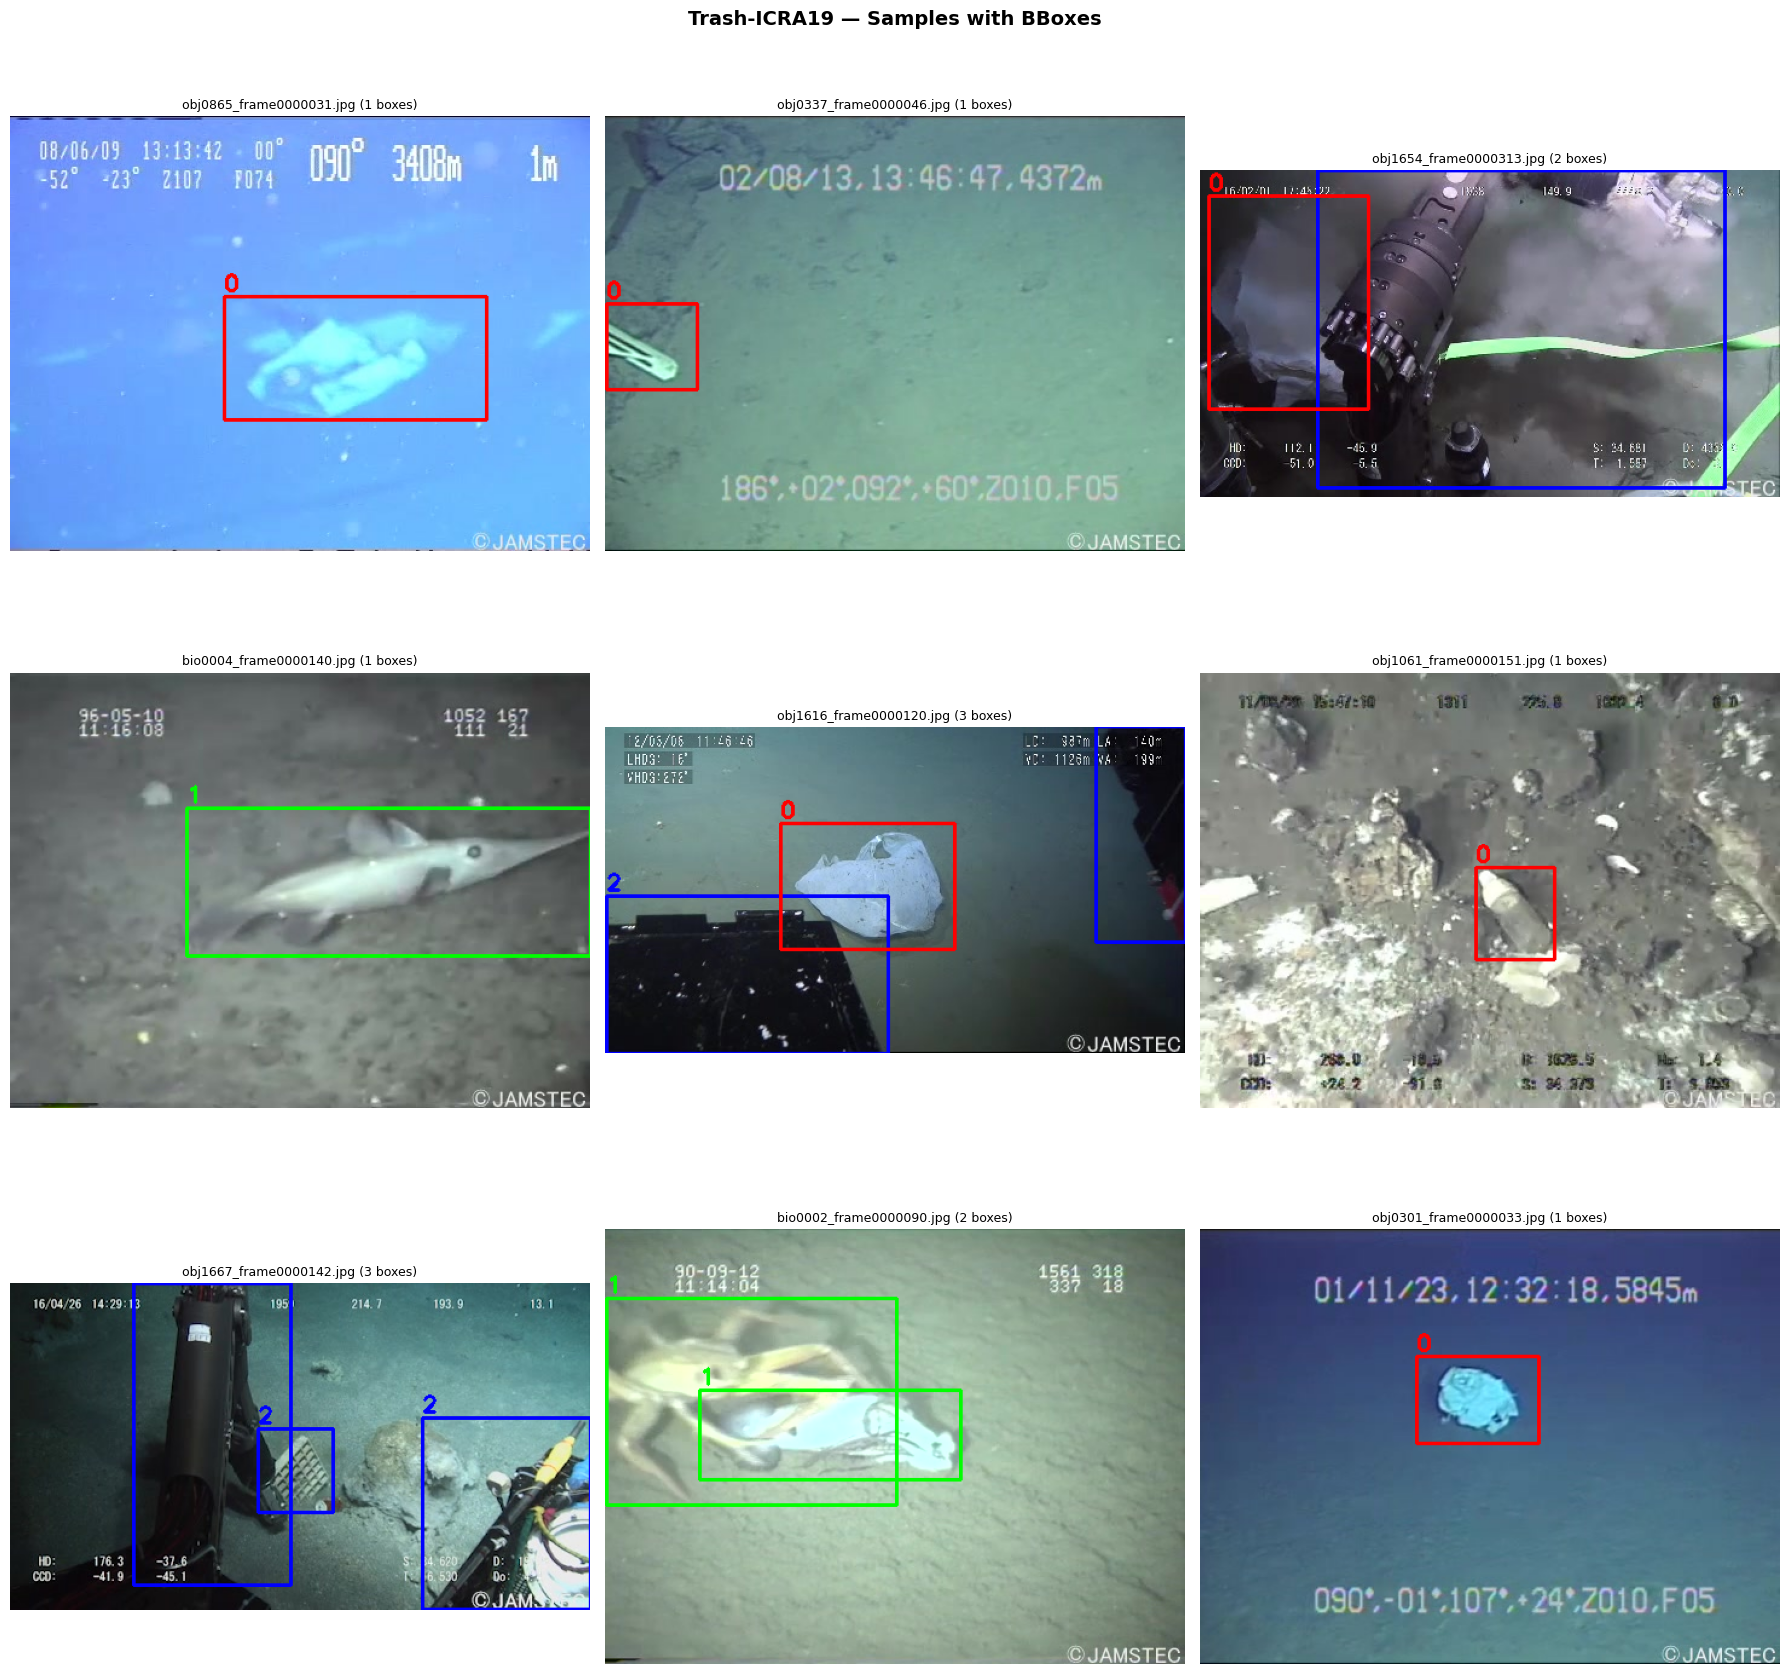

Saved figure: results/figures/trash_icra19_samples.png


In [9]:
# === SAMPLE IMAGES WITH BBOXES ===
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

root = Path(DATASET)

def _resolve_split_dirs(root: Path, split: str) -> tuple[Path, Path]:
    base = root / split
    if not base.exists():
        return base, base
    img_dir = base / "images" if (base / "images").exists() else base
    label_dir = base / "labels" if (base / "labels").exists() else base
    return img_dir, label_dir

train_img_dir, train_label_dir = _resolve_split_dirs(root, "train")
if not train_img_dir.exists():
    raise FileNotFoundError(f"Train images folder not found. Looked for: {train_img_dir}")

jpgs = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    jpgs += list(train_img_dir.glob(ext))
jpgs = sorted(jpgs)
if not jpgs:
    raise FileNotFoundError(f"No train images found in: {train_img_dir}")

np.random.seed(42)
picks = [jpgs[i] for i in np.random.choice(len(jpgs), min(9, len(jpgs)), replace=False)]
COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255),(0,255,255),(128,0,255),(255,128,0),(0,128,255),(128,255,0)]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for idx, p in enumerate(picks):
    ax = axes[idx // 3][idx % 3]
    img = cv2.imread(str(p))
    if img is None:
        ax.axis("off")
        continue
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    txt = (train_label_dir / p.with_suffix(".txt").name)
    nb = 0
    if txt.exists():
        for line in open(txt):
            parts = line.strip().split()
            if len(parts) == 5:
                try:
                    c, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x1, y1 = int((cx - bw / 2) * W), int((cy - bh / 2) * H)
                    x2, y2 = int((cx + bw / 2) * W), int((cy + bh / 2) * H)
                    cv2.rectangle(rgb, (x1, y1), (x2, y2), COLORS[c % len(COLORS)], 2)
                    cv2.putText(rgb, str(c), (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLORS[c % len(COLORS)], 2)
                    nb += 1
                except Exception:
                    pass

    ax.imshow(rgb)
    ax.set_title(f"{p.name} ({nb} boxes)", fontsize=9)
    ax.axis("off")

plt.suptitle("Trash-ICRA19 — Samples with BBoxes", fontsize=14, fontweight="bold")
plt.tight_layout()

out_dir = Path("results") / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "trash_icra19_samples.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {out_path}")

In [10]:
# === FILL THIS SUMMARY AND SHARE WITH TEAM ===
print('''
================================================================
TRASH-ICRA19 EXPLORATION SUMMARY
================================================================
1. Train / Val / Test images: ___ / ___ / ___
2. Number of classes: ___
3. Class mapping:
   0: ___
   1: ___
   (fill all)
4. ROV class present? ___
5. Imbalance ratio: ___x
6. Bad annotations: ___
7. Most common image size: ___
8. Small objects (<1% area): ___%
9. Issues found: ___

READY FOR TRAINING: YES / NO
================================================================
''')



TRASH-ICRA19 EXPLORATION SUMMARY
1. Train / Val / Test images: ___ / ___ / ___
2. Number of classes: ___
3. Class mapping:
   0: ___
   1: ___
   (fill all)
4. ROV class present? ___
5. Imbalance ratio: ___x
6. Bad annotations: ___
7. Most common image size: ___
8. Small objects (<1% area): ___%
9. Issues found: ___

READY FOR TRAINING: YES / NO

